In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
import sys
sys.path.insert(0, "..")

import text_process.text_process as tp

In [4]:
tp.get_stopwords()

{'com',
 'http',
 'https',
 'kod',
 'max',
 'reuters',
 'ru',
 'telegram',
 'а',
 'без',
 'более',
 'больше',
 'будет',
 'будто',
 'бусты',
 'бы',
 'был',
 'была',
 'были',
 'было',
 'быть',
 'в',
 'вам',
 'вас',
 'вдруг',
 'ведь',
 'во',
 'вот',
 'впрочем',
 'все',
 'всегда',
 'всего',
 'всех',
 'всю',
 'вы',
 'где',
 'да',
 'даже',
 'два',
 'для',
 'до',
 'другой',
 'его',
 'ее',
 'ей',
 'ему',
 'если',
 'есть',
 'еще',
 'ж',
 'же',
 'за',
 'зачем',
 'здесь',
 'и',
 'из',
 'или',
 'им',
 'иногда',
 'их',
 'к',
 'как',
 'какая',
 'какой',
 'канал',
 'канале',
 'когда',
 'конечно',
 'которая',
 'которое',
 'которой',
 'которому',
 'которые',
 'который',
 'которыми',
 'кто',
 'куда',
 'ли',
 'лучше',
 'между',
 'меня',
 'мне',
 'много',
 'может',
 'можно',
 'мой',
 'моя',
 'мы',
 'на',
 'над',
 'надо',
 'наконец',
 'нас',
 'не',
 'него',
 'нее',
 'ней',
 'нельзя',
 'нет',
 'ни',
 'нибудь',
 'никогда',
 'ним',
 'них',
 'ничего',
 'но',
 'ну',
 'о',
 'об',
 'один',
 'он',
 'она',
 'они',


In [8]:
url_prefix = 'https://t.me/'
sources = [
    'kommersant',
    'rian_ru',
    'tass_agency',
    'd_code',
    'ENews112',
    'aviadispet4er',
    'headlines_for_traders',
    'mosrutop',
    'rbc_news',
]

parsing_dir = '../data'

In [9]:
def load_data(dir: str, sources: list) -> pd.DataFrame:
    all_dfs = []

    # Loop through all sources and read each CSV file
    for source in sources:
        data_path = f'{parsing_dir}/{source}.csv'
        
        # Check if file exists before reading
        if os.path.exists(data_path):
            df_temp = pd.read_csv(data_path)
            
            # Add channel short name column
            df_temp['channel_short'] = source

            df_temp = df_temp.dropna(subset=['text'])
            
            # Append to the list
            all_dfs.append(df_temp)
            print(f"✓ Loaded {source} with {len(df_temp)} rows")
        else:
            print(f"✗ File not found: {data_path}")

    # Combine all DataFrames into one
    if all_dfs:
        result_df = pd.concat(all_dfs, ignore_index=True)
        
        # Display the combined DataFrame info and first few rows
        print(f"\nCombined DataFrame shape: {result_df.shape}")
        print(f"Total rows: {len(result_df)}")
        print(f"Channels included: {result_df['channel_short'].unique().tolist()}")
        
        # print("\nFirst few rows of combined DataFrame:")
        # print(result_df.head())
        
        # Optional: Save the combined DataFrame to a new CSV file
        result_df.to_csv(f'{parsing_dir}/all_channels_combined.csv', index=False)
        print(f"\n✓ Combined data saved to: {parsing_dir}/all_channels_combined.csv")
    else:
        result_df = pd.DataFrame()
        print("No data was loaded. Please check if the CSV files exist.")

    return result_df

In [10]:
df = load_data(parsing_dir, sources)

✓ Loaded kommersant with 920 rows
✓ Loaded rian_ru with 885 rows
✓ Loaded tass_agency with 948 rows
✓ Loaded d_code with 981 rows
✓ Loaded ENews112 with 567 rows
✓ Loaded aviadispet4er with 615 rows
✓ Loaded headlines_for_traders with 980 rows
✓ Loaded mosrutop with 502 rows
✓ Loaded rbc_news with 927 rows

Combined DataFrame shape: (7325, 7)
Total rows: 7325
Channels included: ['kommersant', 'rian_ru', 'tass_agency', 'd_code', 'ENews112', 'aviadispet4er', 'headlines_for_traders', 'mosrutop', 'rbc_news']

✓ Combined data saved to: ../data/all_channels_combined.csv


In [11]:
df.head()

,id,date,text,views,forwards,replies,channel_short
0,94463,2025-11-01T18:01:06+00:00,🌒 **Главные новости к вечеру **\n\n▪️ Правител...,4179.0,3.0,NaN,kommersant
1,94462,2025-11-01T17:34:42+00:00,**Атомная подводная лодка «Хабаровск» спущена ...,8137.0,40.0,NaN,kommersant
2,94461,2025-11-01T17:14:39+00:00,**Онлайн-банк Revolut начал блокировать счета ...,10314.0,81.0,NaN,kommersant
3,94460,2025-11-01T16:24:55+00:00,"⭐️⭐️⭐️⭐️⭐️⭐️**Образование, ЖКХ, здравоохранени...",12698.0,42.0,NaN,kommersant
4,94459,2025-11-01T16:09:31+00:00,Премьер-министр Венгрии Виктор Обран **назвал ...,12344.0,11.0,NaN,kommersant


In [12]:
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,id,date,text,views,forwards,replies,channel_short
0,324960,2025-11-01T14:32:03+00:00,**Машинист электропоезда призывал подростков з...,273273.0,549.0,NaN,rian_ru
1,23532,2025-09-01T08:51:19+00:00,🤩 **Тяжёлый люкс**\n\nOzon запустил раздел Fas...,38943.0,266.0,17.0,d_code
2,133911,2025-10-21T12:47:06+00:00,**Участие президента Реджепа Тайипа Эрдогана в...,100632.0,50.0,NaN,rbc_news
3,323989,2025-10-25T15:39:36+00:00,❗️Шеф-редактор Sputnik Азербайджан Евгений Бел...,446932.0,69.0,NaN,rian_ru
4,23948,2025-10-13T13:21:35+00:00,🦴 **«Отсутствовали запрещающие знаки»**\n\nВ М...,35214.0,84.0,18.0,d_code


In [13]:
df = tp.apply_text_cleaning(df)

In [14]:
df.head()

,id,date,text,views,forwards,replies,channel_short,text_cleaned
0,324960,2025-11-01T14:32:03+00:00,**Машинист электропоезда призывал подростков з...,273273.0,549.0,NaN,rian_ru,Машинист электропоезда призывал подростков зан...
1,23532,2025-09-01T08:51:19+00:00,🤩 **Тяжёлый люкс**\n\nOzon запустил раздел Fas...,38943.0,266.0,17.0,d_code,Тяжёлый люкс Ozon запустил раздел Fashion Lux ...
2,133911,2025-10-21T12:47:06+00:00,**Участие президента Реджепа Тайипа Эрдогана в...,100632.0,50.0,NaN,rbc_news,Участие президента Реджепа Тайипа Эрдогана в с...
3,323989,2025-10-25T15:39:36+00:00,❗️Шеф-редактор Sputnik Азербайджан Евгений Бел...,446932.0,69.0,NaN,rian_ru,Шеф-редактор Sputnik Азербайджан Евгений Белоу...
4,23948,2025-10-13T13:21:35+00:00,🦴 **«Отсутствовали запрещающие знаки»**\n\nВ М...,35214.0,84.0,18.0,d_code,«Отсутствовали запрещающие знаки» В Минэкологи...


In [15]:
texts_sample = df['text_cleaned'].dropna().astype(str)

In [16]:
corpus = tp.get_tfidf_corpus(texts_sample)
vectorizer = corpus['vectorizer']
matrix = corpus['matrix']
feature_names = corpus['feature_names']

https://habr.com/ru/companies/otus/articles/755772/

In [17]:
tfidf_vectorizer = vectorizer
tfidf_matrix = matrix

feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.toarray()[0]

# Сортировка слов по значениям TF-IDF
sorted_keywords = [word for _, word in sorted(zip(tfidf_scores, feature_names), reverse=True)]

print("Ключевые слова:", sorted_keywords)

Ключевые слова: ['мужчину', 'ск', 'встречи', 'задержали', 'сообщает', 'москве', 'также', 'новости', 'японии', 'яндекс', 'января', 'якобы', 'ядерного', 'является', 'этому', 'это', 'этих', 'этим', 'эта', 'экстремистской', 'эксплуатации', 'эксперты', 'эксперт', 'экс', 'экономики', 'штраф', 'шесть', 'читать', 'читайте', 'число', 'числе', 'четыре', 'честь', 'человека', 'человек', 'чаще', 'часть', 'части', 'часов', 'часа', 'час', 'цены', 'центре', 'центра', 'центр', 'цена', 'цен', 'цб', 'хочет', 'хотят', 'хотя', 'ходе', 'фсб', 'франции', 'фото', 'фоне', 'федерации', 'участников', 'участники', 'участия', 'участие', 'услуг', 'условиях', 'уровне', 'уровень', 'управления', 'управление', 'улице', 'украины', 'украинских', 'украине', 'украина', 'удалось', 'уголовное дело', 'уголовное', 'увидеть', 'тысяч рублей', 'тысяч', 'тыс руб', 'тыс', 'трлн', 'трех', 'транспорта', 'трампа', 'трамп заявил', 'трамп', 'торговли', 'топлива', 'топ', 'типа', 'течение', 'технологии', 'техники', 'тех', 'территории', 'т

In [18]:
from sklearn.cluster import KMeans

# Применение кластеризации KMeans к матрице TF-IDF
num_clusters = 20
kmeans = KMeans(n_clusters=num_clusters, random_state=0)
kmeans.fit(tfidf_matrix)


,n_clusters,20
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [19]:
if False:
    # Показать примеры документов в каждом кластере
    for cluster_id in range(num_clusters):
        cluster_indices = np.where(kmeans.labels_ == cluster_id)[0]
        filename = f'trash/clusters/{cluster_id}.txt'
        print(f"Кластер {cluster_id + 1}: {filename}")
        with open(filename, 'w') as f:
            for idx in cluster_indices:
                print(texts_sample[idx], file=f)
        # print("--------")

https://scikit-learn.ru/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html#sphx-glr-auto-examples-applications-plot-topics-extraction-with-nmf-lda-py

In [20]:
from time import time
from sklearn.decomposition import NMF, LatentDirichletAllocation, MiniBatchNMF

n_samples = len(texts_sample)
n_features = 1000
n_components = 10
n_top_words = 20
batch_size = 128
init = "nndsvda"

def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(2, 5, figsize=(15, 8), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights) #, height=0.7)
        ax.set_title(f"Topic {topic_idx +1}") #, fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major") #, labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title) #, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()


Fitting the NMF model (Frobenius norm) with tf-idf features, n_samples=7325 and n_features=1000...
done in 0.488s.


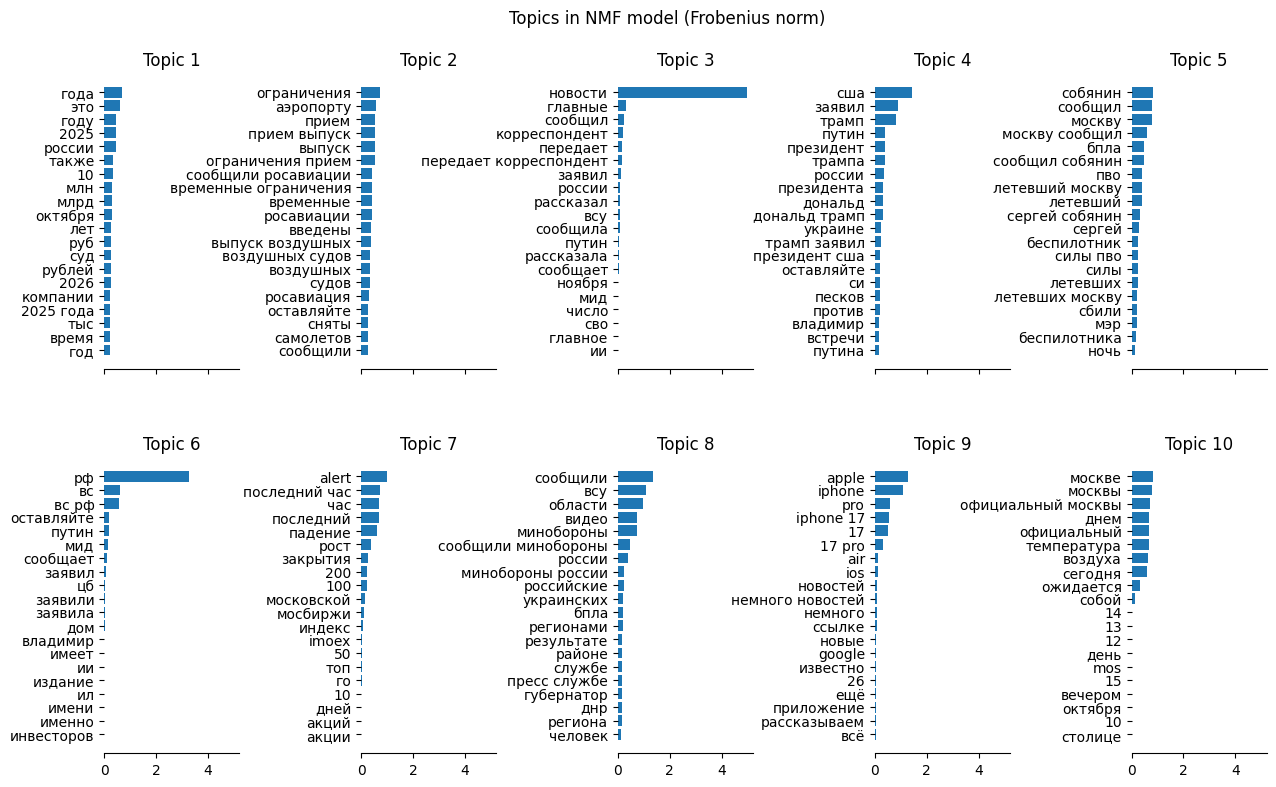

In [21]:
# Fit the NMF model
print(
    "Fitting the NMF model (Frobenius norm) with tf-idf features, "
    "n_samples=%d and n_features=%d..." % (n_samples, n_features)
)
t0 = time()
tfidf = tfidf_matrix
nmf = NMF(
    n_components=n_components,
    random_state=1,
    init=init,
    beta_loss="frobenius",
    alpha_W=0.00005,
    alpha_H=0.00005,
    l1_ratio=1,
).fit(tfidf)
print("done in %0.3fs." % (time() - t0))


tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(
    nmf, tfidf_feature_names, n_top_words, "Topics in NMF model (Frobenius norm)"
)



 Fitting the NMF model (generalized Kullback-Leibler divergence) with tf-idf features, n_samples=7325 and n_features=1000...
done in 2.932s.


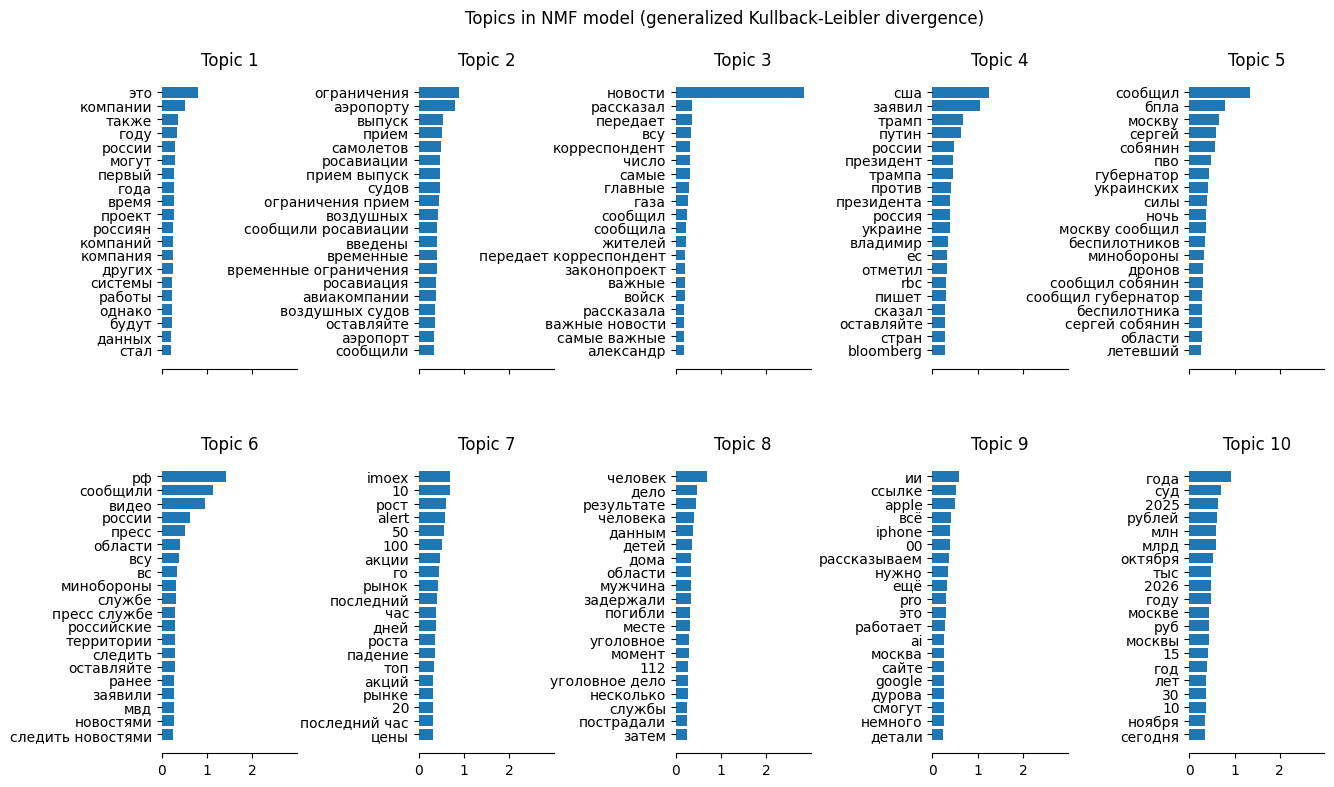

In [22]:
# Fit the NMF model
print(
    "\n" * 2,
    "Fitting the NMF model (generalized Kullback-Leibler "
    "divergence) with tf-idf features, n_samples=%d and n_features=%d..."
    % (n_samples, n_features),
)
t0 = time()
nmf = NMF(
    n_components=n_components,
    random_state=1,
    init=init,
    beta_loss="kullback-leibler",
    solver="mu",
    max_iter=1000,
    alpha_W=0.00005,
    alpha_H=0.00005,
    l1_ratio=0.5,
).fit(tfidf)
print("done in %0.3fs." % (time() - t0))

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(
    nmf,
    tfidf_feature_names,
    n_top_words,
    "Topics in NMF model (generalized Kullback-Leibler divergence)",
)



 Fitting the MiniBatchNMF model (Frobenius norm) with tf-idf features, n_samples=7325 and n_features=1000, batch_size=128...
done in 0.211s.


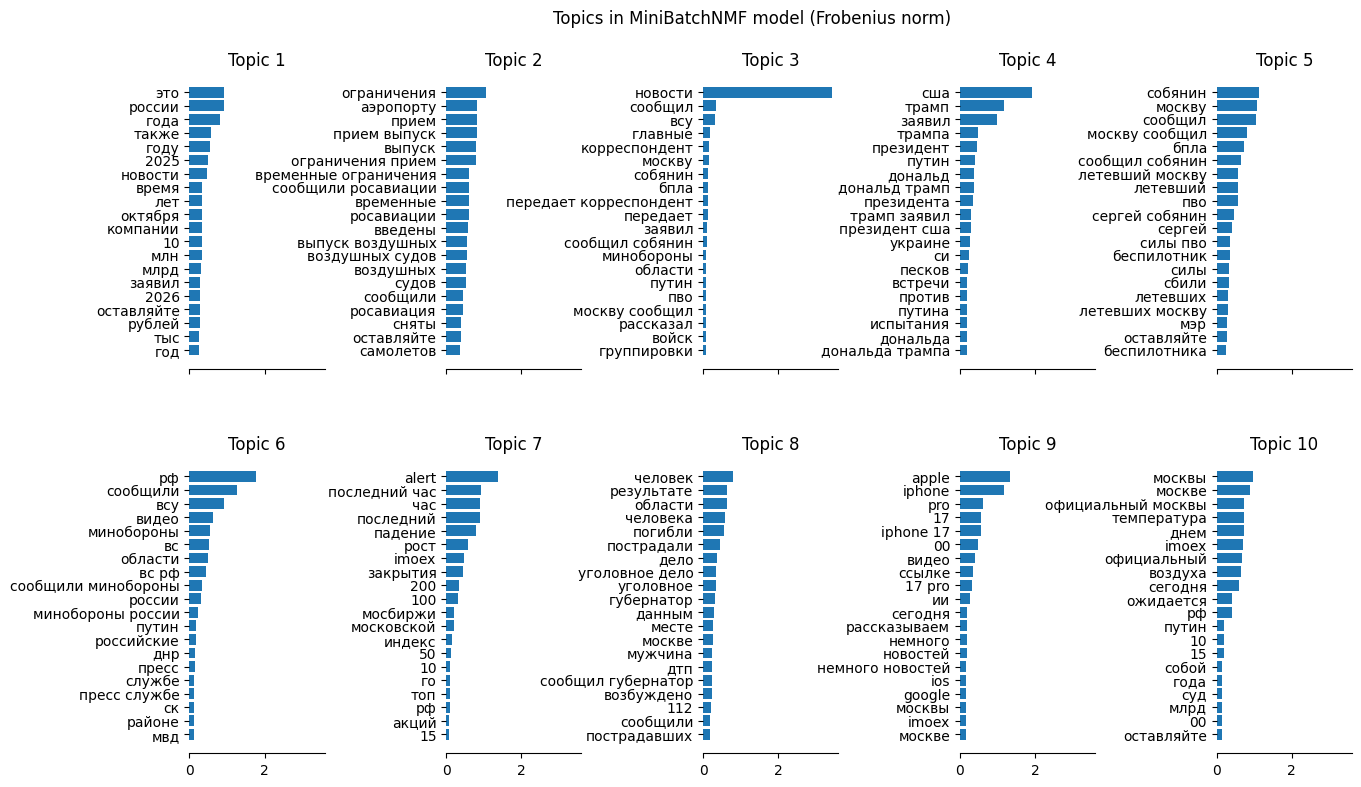

In [23]:
# Fit the MiniBatchNMF model
print(
    "\n" * 2,
    "Fitting the MiniBatchNMF model (Frobenius norm) with tf-idf "
    "features, n_samples=%d and n_features=%d, batch_size=%d..."
    % (n_samples, n_features, batch_size),
)
t0 = time()
mbnmf = MiniBatchNMF(
    n_components=n_components,
    random_state=1,
    batch_size=batch_size,
    init=init,
    beta_loss="frobenius",
    alpha_W=0.00005,
    alpha_H=0.00005,
    l1_ratio=0.5,
).fit(tfidf)
print("done in %0.3fs." % (time() - t0))


tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(
    mbnmf,
    tfidf_feature_names,
    n_top_words,
    "Topics in MiniBatchNMF model (Frobenius norm)",
)



 Fitting the MiniBatchNMF model (generalized Kullback-Leibler divergence) with tf-idf features, n_samples=7325 and n_features=1000, batch_size=128...
done in 0.768s.


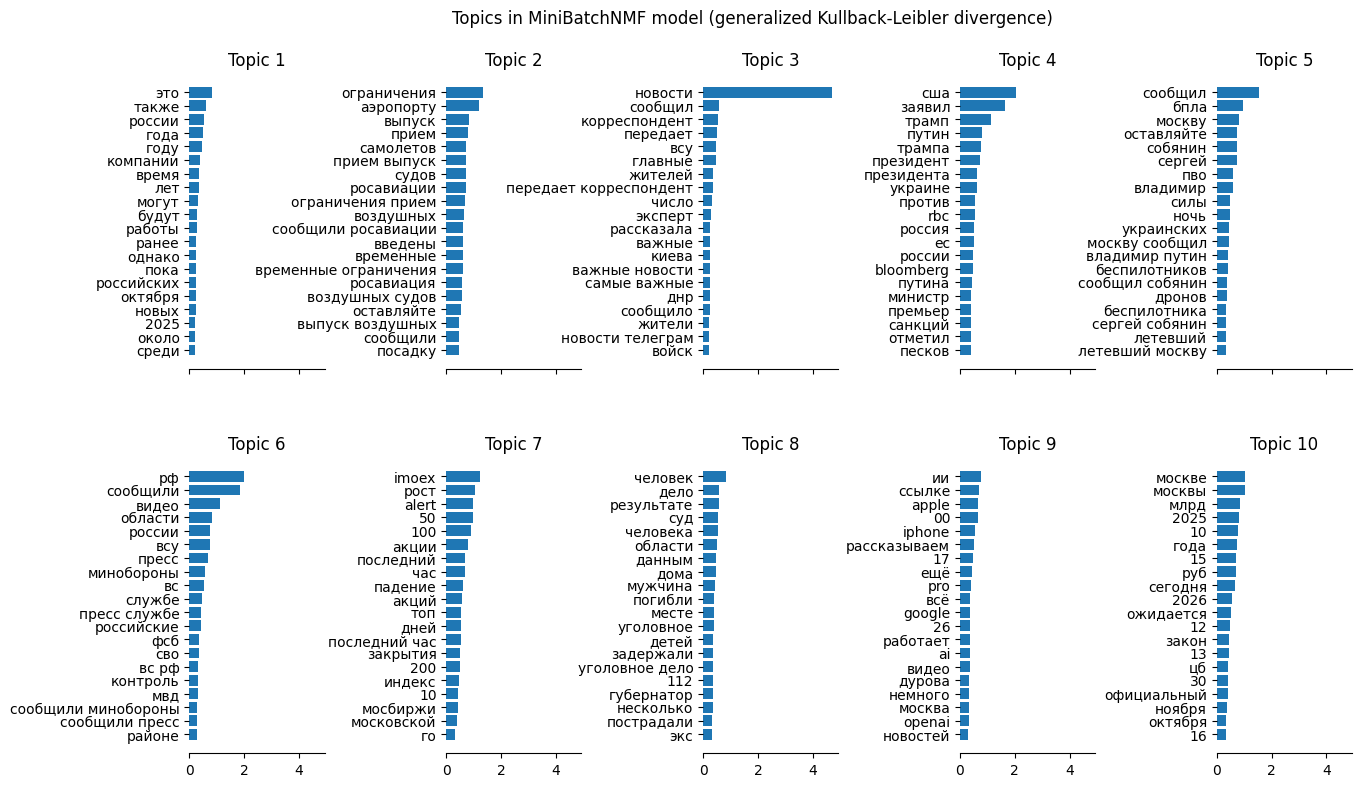

In [24]:
# Fit the MiniBatchNMF model
print(
    "\n" * 2,
    "Fitting the MiniBatchNMF model (generalized Kullback-Leibler "
    "divergence) with tf-idf features, n_samples=%d and n_features=%d, "
    "batch_size=%d..." % (n_samples, n_features, batch_size),
)
t0 = time()
mbnmf = MiniBatchNMF(
    n_components=n_components,
    random_state=1,
    batch_size=batch_size,
    init=init,
    beta_loss="kullback-leibler",
    alpha_W=0.00005,
    alpha_H=0.00005,
    l1_ratio=0.5,
).fit(tfidf)
print("done in %0.3fs." % (time() - t0))

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(
    mbnmf,
    tfidf_feature_names,
    n_top_words,
    "Topics in MiniBatchNMF model (generalized Kullback-Leibler divergence)",
)



 Fitting LDA models with tf features, n_samples=7325 and n_features=1000...
done in 5.565s.


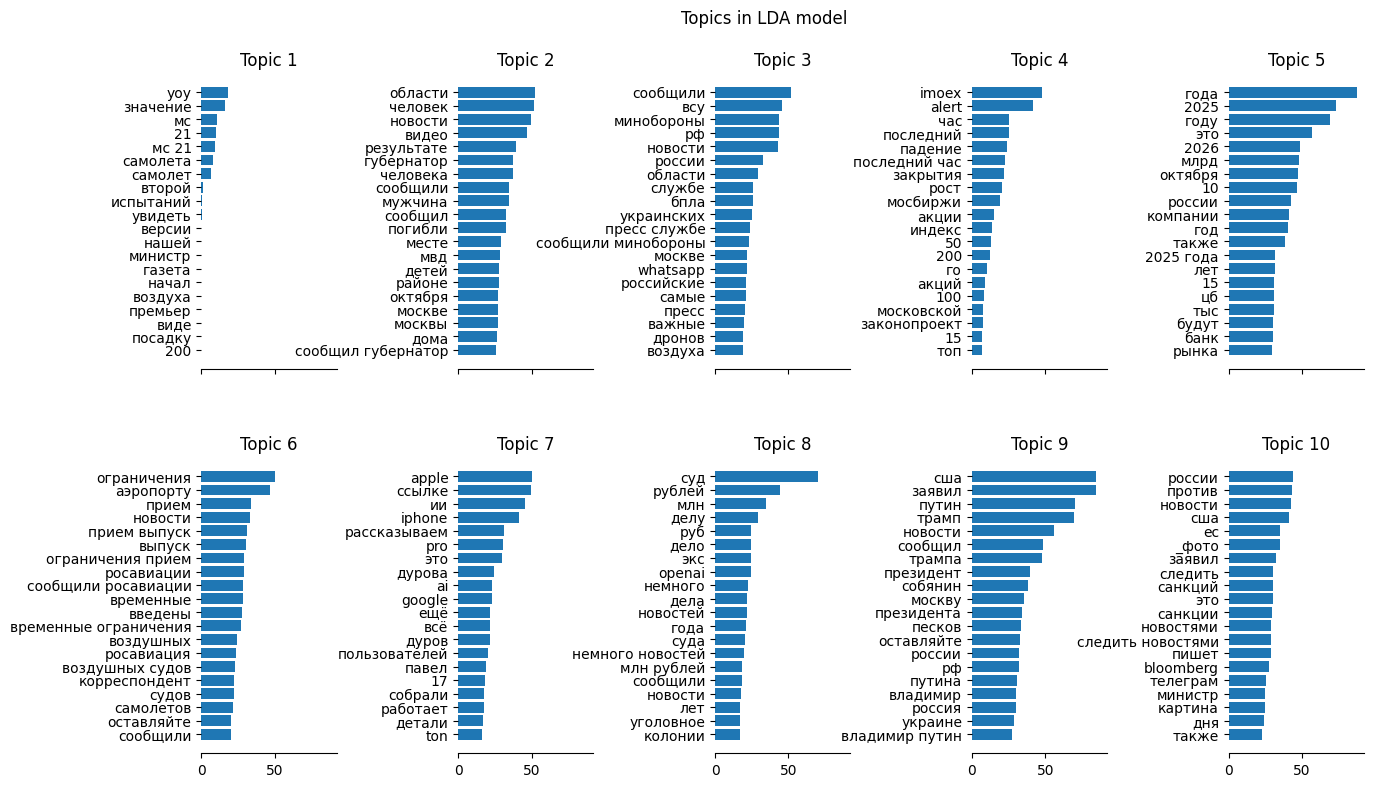

In [25]:
print(
    "\n" * 2,
    "Fitting LDA models with tf features, n_samples=%d and n_features=%d..."
    % (n_samples, n_features),
)
lda = LatentDirichletAllocation(
    n_components=n_components,
    max_iter=5,
    learning_method="online",
    learning_offset=50.0,
    random_state=0,
)
t0 = time()
lda.fit(tfidf)
print("done in %0.3fs." % (time() - t0))

tf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(lda, tf_feature_names, n_top_words, "Topics in LDA model")

# Метрики

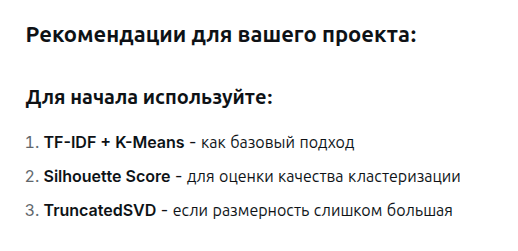

In [26]:
X_tfidf = matrix

In [27]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=10, random_state=42)

In [28]:
cluster_labels = kmeans.fit_predict(X_tfidf)

In [29]:
from sklearn.metrics import silhouette_score

# Вычисление для TF-IDF векторов
silhouette_avg = silhouette_score(X_tfidf, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.3f}")

# Плюсы:
# Не требует размеченных данных
# Учитывает как компактность кластеров, так и разделимость
# Диапазон от -1 до 1 (чем ближе к 1, тем лучше)

# Минусы:
# Может быть высоким для "плохих" кластеров с геометрически правильной формой
# Вычислительно дорогой для больших датасетов

Silhouette Score: 0.023


In [30]:
#deepseek
def analyze_clusters_tfidf(results, texts, top_n_words=10):
    """
    Анализ тематик кластеров на основе TF-IDF
    """
    vectorizer = results['vectorizer']
    model = results['model']
    cluster_labels = results['cluster_labels']
    
    feature_names = vectorizer.get_feature_names_out()
    
    print("=== ТЕМАТИКИ КЛАСТЕРОВ ===")
    for cluster_id in range(model.n_clusters):
        # Индексы центроида кластера
        centroid = model.cluster_centers_[cluster_id]
        
        # Топ-N слов с наибольшим весом
        top_indices = centroid.argsort()[-top_n_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        
        # Количество новостей в кластере
        cluster_size = np.sum(cluster_labels == cluster_id)
        
        print(f"\nКластер {cluster_id} ({cluster_size} новостей):")
        print(f"Ключевые слова: {', '.join(top_words)}")
        
        # Примеры новостей из кластера
        cluster_texts = [texts[i] for i, label in enumerate(cluster_labels) if label == cluster_id]
        print(f"Пример: {cluster_texts[0][:100]}...")



In [31]:
corpus = tp.get_tfidf_corpus(texts_sample)
vectorizer = corpus['vectorizer']
matrix = corpus['matrix']
feature_names = corpus['feature_names']

results = {
    'vectorizer': vectorizer,
    'model': kmeans,
    'cluster_labels': cluster_labels
}

# Использование
analyze_clusters_tfidf(results, texts_sample)

=== ТЕМАТИКИ КЛАСТЕРОВ ===

Кластер 0 (698 новостей):
Ключевые слова: новости, сообщил, собянин, москву, москву сообщил, бпла, сообщил собянин, россии, заявил, летевший москву
Пример: Машинист электропоезда призывал подростков заниматься зацепингом в Москве, сообщает СК. Он регулярно...

Кластер 1 (148 новостей):
Ключевые слова: imoex, alert, последний час, падение, час, последний, закрытия, рост, мосбиржи, 200
Пример: #alert SILVER (XAG/USD): падение > 2.5% за последний час...

Кластер 2 (330 новостей):
Ключевые слова: рф, вс, вс рф, заявил, сообщили, россии, оставляйте, путин, всу, мид
Пример: Пятилетний мораторий на повышение налогов для малого бизнеса нужно ввести в России. Это станет гаран...

Кластер 3 (1124 новостей):
Ключевые слова: октября, это, 00, время, также, дня, телеграм, ноября, россии, 30
Пример: "Вонючая Европа" в будущем будет платить Белоруссии за чистый воздух, считает Лукашенко: "Это [чисты...

Кластер 4 (504 новостей):
Ключевые слова: суд, рублей, дело, млн, угол

In [32]:
# deepseek
# 4. Модели для рекомендаций
# Cosine Similarity (Для поиска похожих новостей)
# python
from sklearn.metrics.pairwise import cosine_similarity

# Матрица попарных схожестей
similarity_matrix = cosine_similarity(X_tfidf)


In [33]:
# Найти похожие на первую новость
similar_news_indices = similarity_matrix[6].argsort()[-10:][::-1]

for post in texts_sample[similar_news_indices][:5]:
    print(post, end='\n\n')

В московском метро открылась новая фотовыставка. Она посвящена 80-летию Приокско-Террасного заповедника. Пассажиры увидят кадры с дикими животными: лосями, косулями, белками, барсуками, лисами, кабанами, зубрами. Снимками можно полюбоваться до 4 ноября. Верхний ярус транспортного хаба «Деловой центр»

Эксклюзивные кадры _«В небе над Балтикой»_

Приглашаем на обучение в центр «Профессии будущего». Учащиеся совершенствуют навыки на уникальных площадках: на точной копии станции метро, в двухуровневой лифтовой шахте, учебном отеле и профессиональном ресторане. Центр сотрудничает более чем с тремя тысячами компаний, ежегодно готовит 15 тысяч специалистов по 75 востребованным профессиям. Выпускники получают дипломы государственного образца и помощь в трудоустройстве. Записаться на обучение можно на сайте.

На МЦД-2 с 2 по 4 ноября изменится расписание движения поездов. Составы будут следовать с увеличенными интервалами и без остановок на некоторых платформах, сквозные поездки ограничат. Пасс

# От Дипсика:

Я хочу взять KMeans и сгруппировать новости. Но я не хочу заранее задавать количество кластеров. Как сделать кластеризацию, не зная заранее количество кластеров?

1. Метод локтя (Elbow Method) - Самый популярный
2. Метод силуэта (Silhouette Analysis) - Более надежный
3. Автоматический подход с поиском по сетке
4. Альтернатива: Использование алгоритмов, которые не требуют k
(DBSCAN - не требует указания числа кластеров)

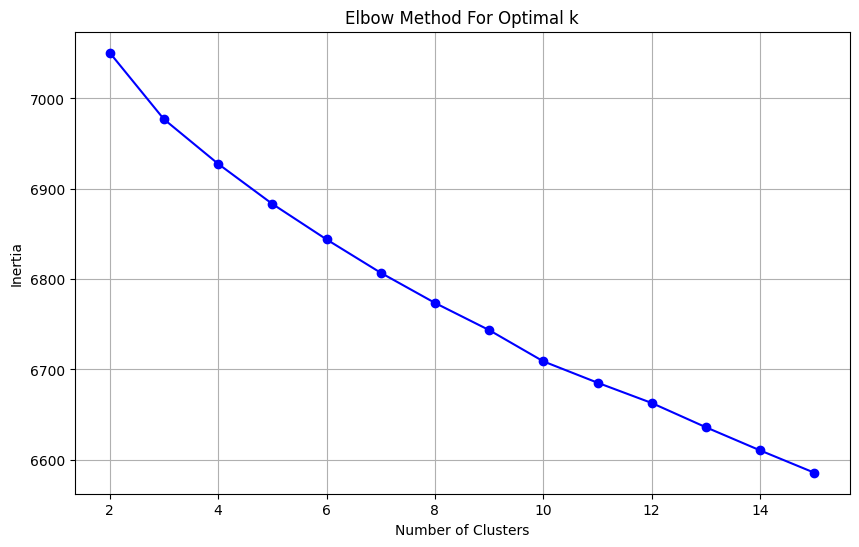

In [34]:
# 1. Метод локтя (Elbow Method) - Самый популярный

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

def find_optimal_clusters_elbow(X_tfidf, max_k=15):
    """
    Метод локтя для определения оптимального числа кластеров
    """
    inertias = []
    k_range = range(2, max_k + 1)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_tfidf)
        inertias.append(kmeans.inertia_)  # Сумма квадратов расстояний до центроидов
    
    # Визуализация
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, inertias, 'bo-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.title('Elbow Method For Optimal k')
    plt.grid(True)
    plt.show()
    
    return inertias

# Использование
inertias = find_optimal_clusters_elbow(X_tfidf, max_k=15)

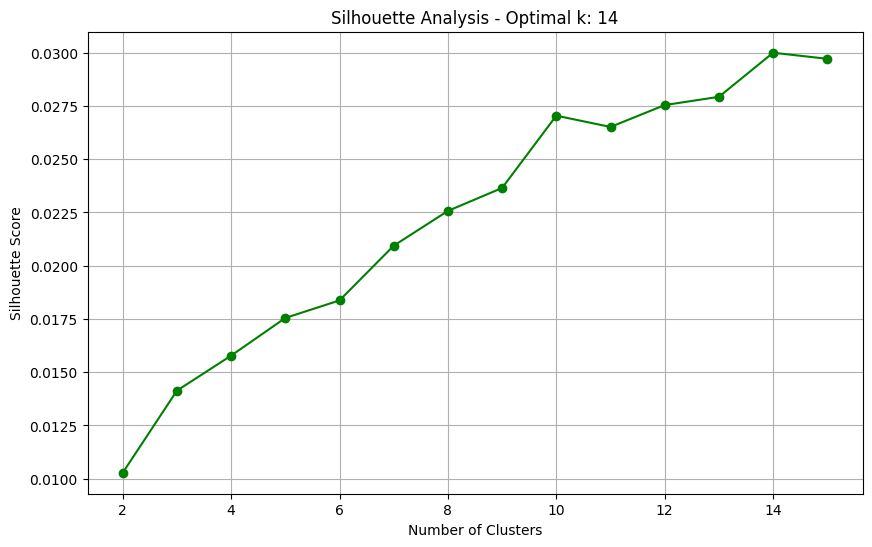

Оптимальное число кластеров: 14


In [35]:
# 2. Метод силуэта (Silhouette Analysis) - Более надежный

def find_optimal_clusters_silhouette(X_tfidf, max_k=15):
    """
    Метод силуэта для определения оптимального числа кластеров
    """
    silhouette_scores = []
    k_range = range(2, max_k + 1)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X_tfidf)
        
        # Вычисляем silhouette score
        if len(set(cluster_labels)) > 1:  # Нужно хотя бы 2 кластера
            score = silhouette_score(X_tfidf, cluster_labels)
            silhouette_scores.append(score)
        else:
            silhouette_scores.append(0)
    
    # Находим оптимальное k
    optimal_k = k_range[np.argmax(silhouette_scores)]
    
    # Визуализация
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, silhouette_scores, 'go-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.title(f'Silhouette Analysis - Optimal k: {optimal_k}')
    plt.grid(True)
    plt.show()
    
    return optimal_k, silhouette_scores

# Использование
optimal_k, scores = find_optimal_clusters_silhouette(X_tfidf)
print(f"Оптимальное число кластеров: {optimal_k}")

=== РЕЗУЛЬТАТЫ АВТОМАТИЧЕСКОГО ПОИСКА ===
Лучшее k по Silhouette: 20 (score: 0.037)
Лучшее k по Calinski-Harabasz: 3 (score: 73)


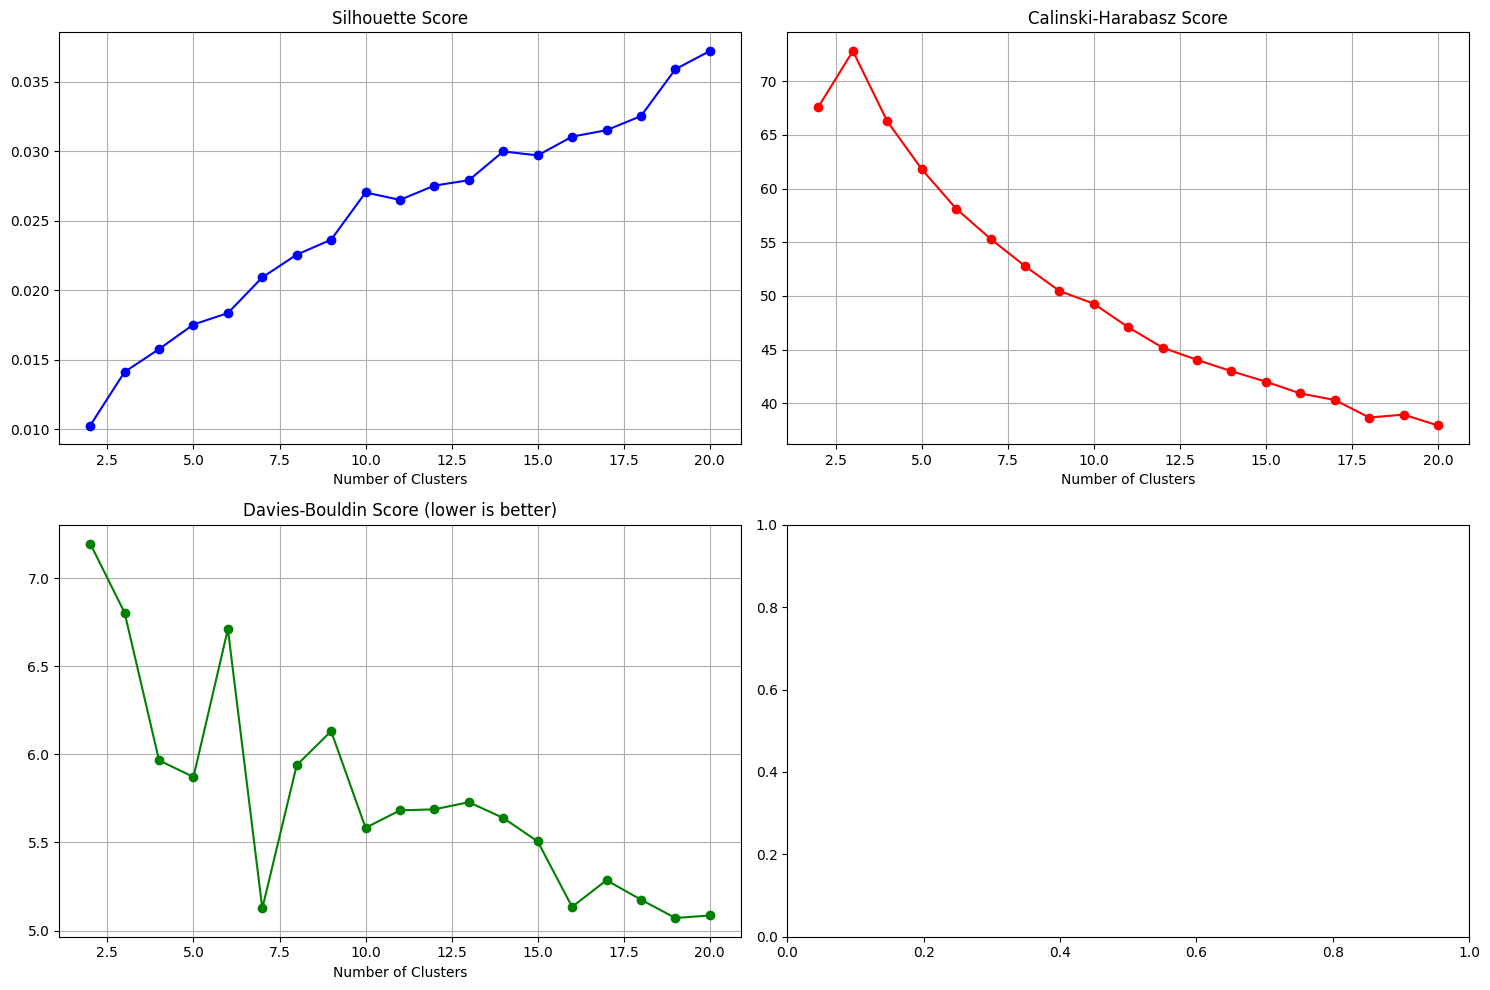

In [36]:
# 3. Автоматический подход с поиском по сетке

from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

def find_best_k_automated(X_tfidf, min_k=2, max_k=20):
    """
    Автоматический поиск лучшего k по нескольким метрикам
    """
    results = []
    
    for k in range(min_k, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_tfidf)
        
        # Пропускаем если только один кластер
        if len(set(labels)) < 2:
            continue
            
        # Вычисляем несколько метрик
        silhouette = silhouette_score(X_tfidf, labels)
        calinski = calinski_harabasz_score(X_tfidf.toarray(), labels)
        davies = davies_bouldin_score(X_tfidf.toarray(), labels)
        
        results.append({
            'k': k,
            'silhouette': silhouette,
            'calinski_harabasz': calinski,
            'davies_bouldin': davies,
            'model': kmeans,
            'labels': labels
        })
    
    # Создаем DataFrame для анализа
    results_df = pd.DataFrame(results)
    
    # Находим лучшие k по разным метрикам
    best_silhouette = results_df.loc[results_df['silhouette'].idxmax()]
    best_calinski = results_df.loc[results_df['calinski_harabasz'].idxmax()]
    
    print("=== РЕЗУЛЬТАТЫ АВТОМАТИЧЕСКОГО ПОИСКА ===")
    print(f"Лучшее k по Silhouette: {best_silhouette['k']} (score: {best_silhouette['silhouette']:.3f})")
    print(f"Лучшее k по Calinski-Harabasz: {best_calinski['k']} (score: {best_calinski['calinski_harabasz']:.0f})")
    
    # Визуализация всех метрик
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    axes[0,0].plot(results_df['k'], results_df['silhouette'], 'bo-')
    axes[0,0].set_title('Silhouette Score')
    axes[0,0].set_xlabel('Number of Clusters')
    axes[0,0].grid(True)
    
    axes[0,1].plot(results_df['k'], results_df['calinski_harabasz'], 'ro-')
    axes[0,1].set_title('Calinski-Harabasz Score')
    axes[0,1].set_xlabel('Number of Clusters')
    axes[0,1].grid(True)
    
    axes[1,0].plot(results_df['k'], results_df['davies_bouldin'], 'go-')
    axes[1,0].set_title('Davies-Bouldin Score (lower is better)')
    axes[1,0].set_xlabel('Number of Clusters')
    axes[1,0].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return results_df, best_silhouette

# Использование
results_df, best_result = find_best_k_automated(X_tfidf)
optimal_kmeans = best_result['model']
optimal_labels = best_result['labels']

In [37]:
# 4. Альтернатива: Использование алгоритмов, которые не требуют k
# DBSCAN - не требует указания числа кластеров

from sklearn.cluster import DBSCAN

def cluster_with_dbscan(X_tfidf, eps=0.5, min_samples=5):
    """
    Кластеризация с DBSCAN (не требует указания числа кластеров)
    """
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_tfidf)
    
    # Анализ результатов
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"Найдено кластеров: {n_clusters}")
    print(f"Шумовых точек: {n_noise} ({n_noise/len(labels)*100:.1f}%)")
    
    if n_clusters > 0:
        silhouette = silhouette_score(X_tfidf, labels)
        print(f"Silhouette Score: {silhouette:.3f}")
    
    return labels, dbscan

# Поиск оптимальных параметров для DBSCAN
def optimize_dbscan(X_tfidf):
    """
    Подбор параметров для DBSCAN
    """
    results = []
    
    for eps in [0.3, 0.4, 0.5, 0.6, 0.7]:
        for min_samples in [3, 5, 7, 10]:
            labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_tfidf)
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            
            if n_clusters > 1:  # Нужно хотя бы 2 кластера
                silhouette = silhouette_score(X_tfidf, labels)
                results.append({
                    'eps': eps,
                    'min_samples': min_samples,
                    'n_clusters': n_clusters,
                    'silhouette': silhouette
                })
    
    results_df = pd.DataFrame(results)
    best_result = results_df.loc[results_df['silhouette'].idxmax()]
    
    print(f"Лучшие параметры: eps={best_result['eps']}, min_samples={best_result['min_samples']}")
    print(f"Кластеров: {best_result['n_clusters']}, Silhouette: {best_result['silhouette']:.3f}")
    
    return best_result

# Использование DBSCAN
best_dbscan_params = optimize_dbscan(X_tfidf)
labels, dbscan_model = cluster_with_dbscan(
    X_tfidf, 
    eps=best_dbscan_params['eps'], 
    min_samples=int(best_dbscan_params['min_samples'])
)

Лучшие параметры: eps=0.7, min_samples=3.0
Кластеров: 82.0, Silhouette: -0.203
Найдено кластеров: 82
Шумовых точек: 6397 (87.3%)
Silhouette Score: -0.203


In [38]:
labels = dbscan_model.fit_predict(X=X_tfidf)
labels

array([-1, -1, -1, ...,  0, -1, -1], shape=(7325,))

In [39]:
from sklearn.decomposition import PCA
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_tfidf.toarray())

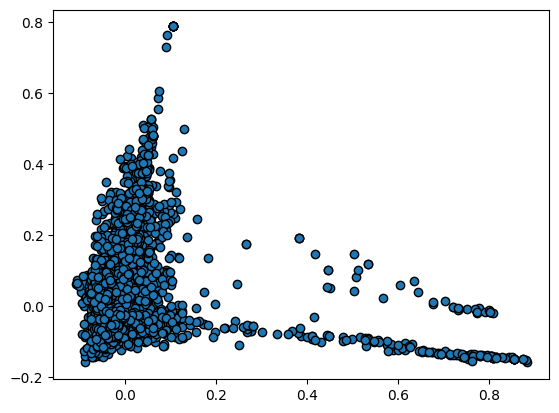

In [40]:
plt.plot(X_pca[:, 0], X_pca[:, 1], 'o', #markerfacecolor=tuple(col),
    markeredgecolor='k', #markersize=8 if k == -1 else 10,
    # label=f'Cluster {k}' if k != -1 else 'Noise'
    )

In [41]:
#deepseek
from sklearn.manifold import TSNE

def visualize_with_tsne(cluster_labels, X_tfidf):
    """
    Визуализация с t-SNE (лучше сохраняет локальные расстояния)
    """
    
    
    # Используем t-SNE вместо PCA
    tsne = TSNE(n_components=2, random_state=42, 
                perplexity=30)
    X_tsne = tsne.fit_transform(X_tfidf.toarray())
    
    # Визуализация
    plt.figure(figsize=(10, 8))
    
    unique_labels = set(cluster_labels)
    colors = plt.cm.Set2(np.linspace(0, 1, len(unique_labels)))
    
    for label, color in zip(unique_labels, colors):
        mask = cluster_labels == label
        plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=[color], label=f'Cluster {label}',
                   alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
    
    # Настройки как на вашей картинке
    plt.xlabel('t-SNE 1', fontsize=12)
    plt.ylabel('t-SNE 2', fontsize=12)
    plt.title('News Clusters (t-SNE)', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return X_tsne

/tmp/ipykernel_302394/3942374478.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


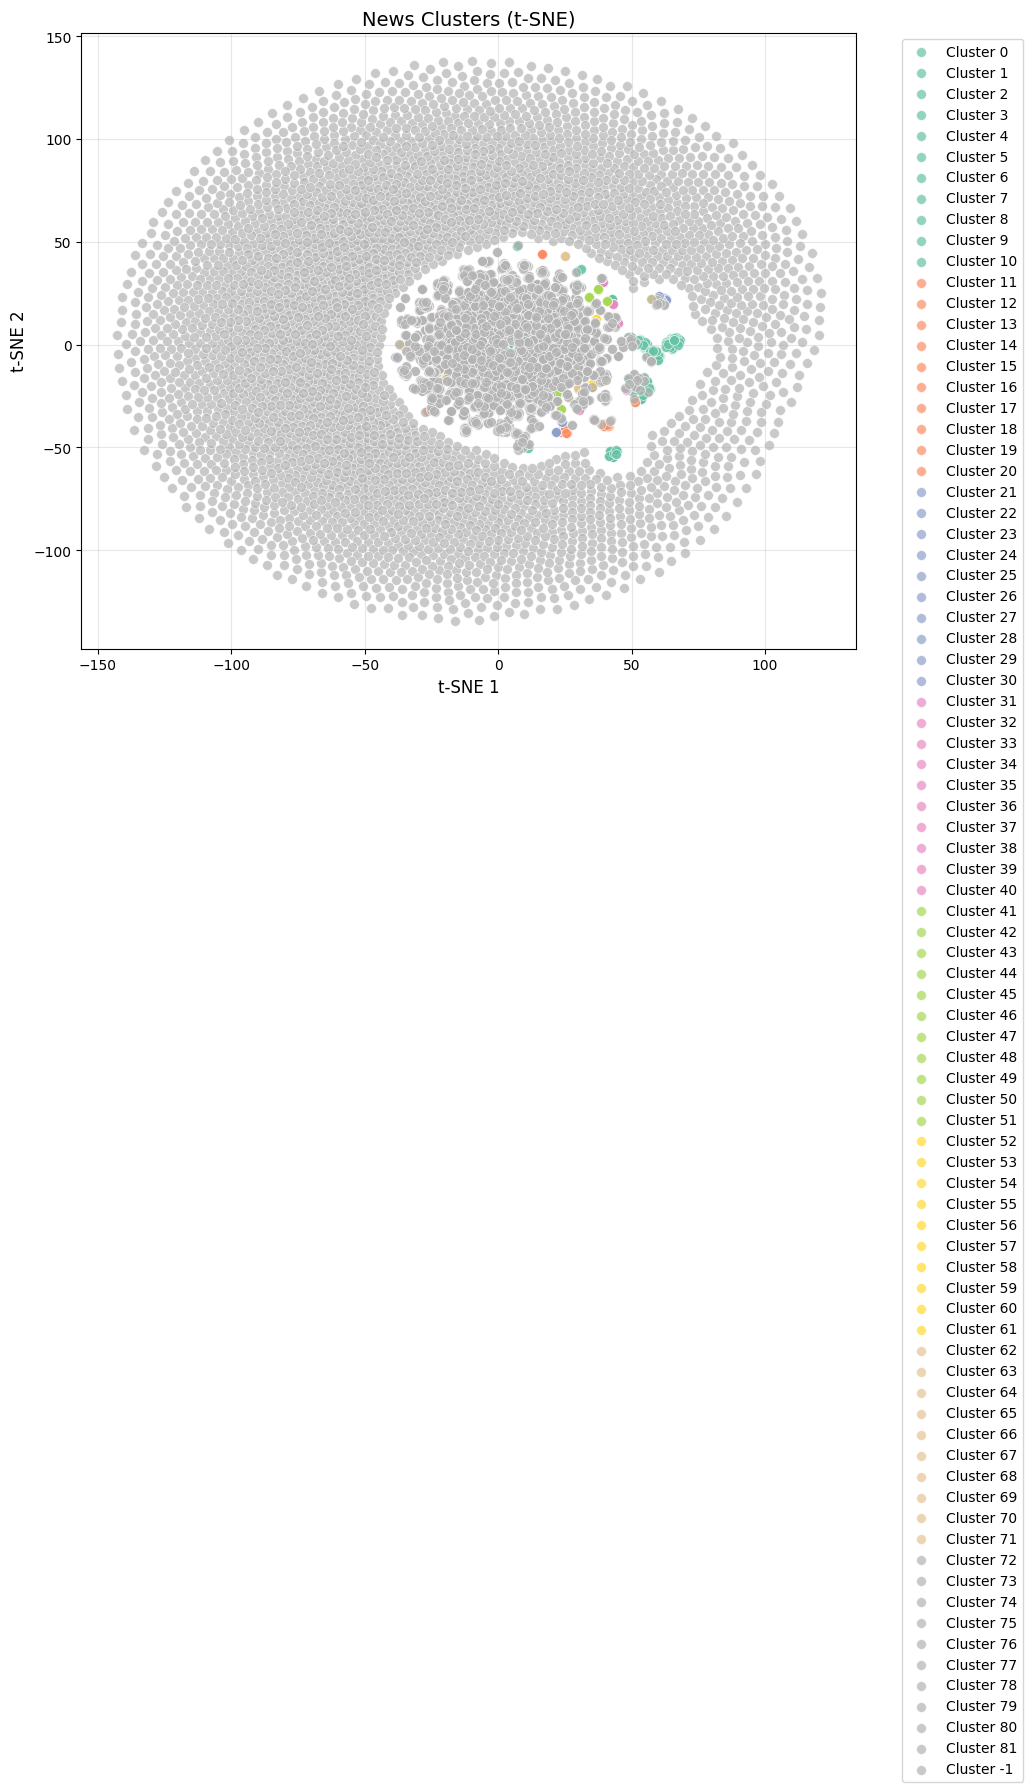

array([[-82.69733  ,  91.489525 ],
       [-54.879375 , -92.62282  ],
       [-99.707954 ,  55.031353 ],
       ...,
       [ 58.032276 ,  -3.0898547],
       [ 17.924343 , -30.448616 ],
       [ 25.159475 ,   5.1673245]], shape=(7325, 2), dtype=float32)

In [42]:
visualize_with_tsne(labels, X_tfidf)

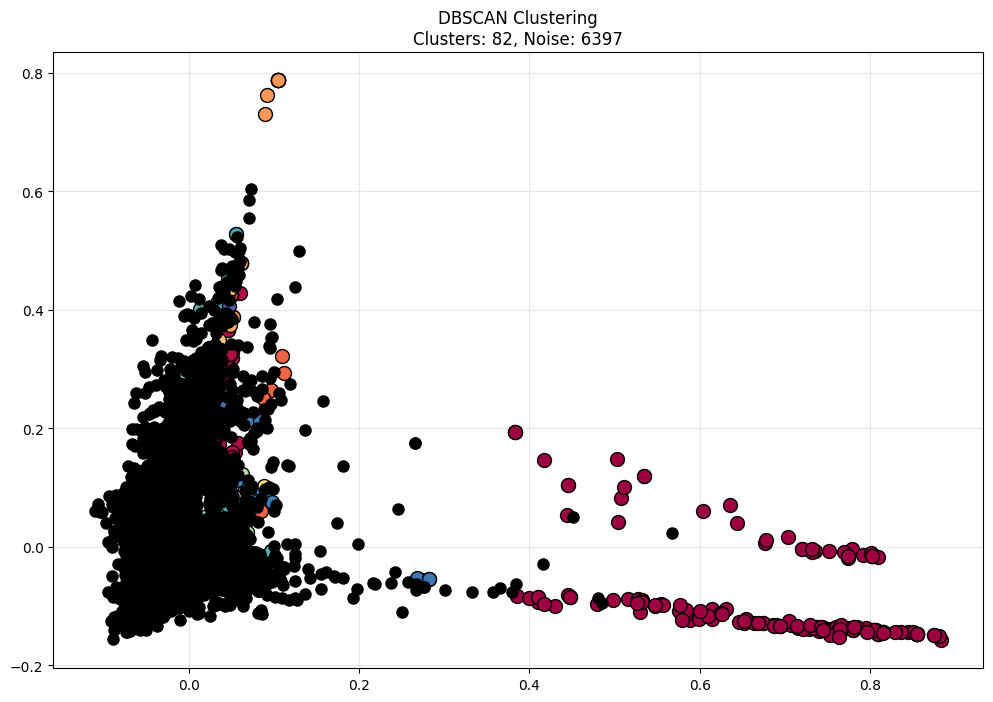

In [43]:
#deepseek
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_dbscan_clusters(X, labels, title="DBSCAN Clustering"):
    """
    Визуализация кластеров DBSCAN с помощью PCA
    """
    # Уменьшаем размерность для визуализации
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X.toarray())  # Для sparse матриц используем .toarray()
    
    # Создаем цветовую карту
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    
    plt.figure(figsize=(12, 8))
    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Шум черным цветом
            col = [0, 0, 0, 1]
        
        class_member_mask = (labels == k)
        xy = X_pca[class_member_mask]
        plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                 markeredgecolor='k', markersize=8 if k == -1 else 10,
                 label=f'Cluster {k}' if k != -1 else 'Noise')
    
    plt.title(f'{title}\nClusters: {len(unique_labels) - 1}, Noise: {np.sum(labels == -1)}')
    # plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Использование
visualize_dbscan_clusters(X_tfidf, labels)